In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from xgboost import XGBRegressor

df = pd.read_csv('correlation_demand_data_2025.csv')
df

,Unnamed: 0,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,...,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
0,0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,...,False,False,True,NaN,NaN,NaN,19918.000000,5405,0.271363,14513
1,1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,...,False,False,True,19918.0,NaN,NaN,20042.500000,5358,0.265682,14809
2,2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,...,False,False,True,20167.0,19918.0,NaN,20137.666667,5237,0.257625,15091
3,3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,...,False,False,True,20328.0,20167.0,NaN,19968.250000,5115,0.262847,14345
4,4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,...,False,False,True,19460.0,20328.0,NaN,19705.400000,5080,0.272328,13574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,17515,2025-12-31 21:30:00,44,28633,30690,26868,3994,6606,0,22126,...,False,False,False,27896.0,29072.0,29056.0,28162.041667,3994,0.148653,22874
17516,17516,2025-12-31 22:00:00,45,27381,30212,25722,4027,6606,0,22126,...,False,False,False,26868.0,27896.0,27917.0,28116.312500,4027,0.156559,21695
17517,17517,2025-12-31 22:30:00,46,26563,29786,25049,4059,6606,0,22126,...,False,False,False,25722.0,26868.0,26598.0,28084.041667,4059,0.162042,20990
17518,17518,2025-12-31 23:00:00,47,25481,30558,23955,4115,6606,0,22126,...,False,False,True,25049.0,25722.0,25493.0,28052.000000,4115,0.171780,19840


In [3]:
df.drop('Unnamed: 0', axis='columns', inplace=True)
df.head()

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,False,False,True,NaN,NaN,NaN,19918.000000,5405,0.271363,14513
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,False,False,True,19918.0,NaN,NaN,20042.500000,5358,0.265682,14809
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,False,False,True,20167.0,19918.0,NaN,20137.666667,5237,0.257625,15091
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,False,False,True,20328.0,20167.0,NaN,19968.250000,5115,0.262847,14345
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,False,False,True,19460.0,20328.0,NaN,19705.400000,5080,0.272328,13574


In [13]:
# calculating the morning ramp

df['demand_change_30m'] = df['england_wales_demand'].diff()
average_morning_ramp = df[df['is_morning_peak'] == True].groupby('timestamp')['demand_change_30m'].mean()
average_morning_ramp

timestamp
2025-01-01 07:00:00     610.0
2025-01-01 07:30:00      76.0
2025-01-01 08:00:00     517.0
2025-01-01 08:30:00     711.0
2025-01-01 09:00:00    1355.0
                        ...  
2025-12-31 07:30:00     729.0
2025-12-31 08:00:00    1592.0
2025-12-31 08:30:00    1113.0
2025-12-31 09:00:00    1021.0
2025-12-31 09:30:00      60.0
Name: demand_change_30m, Length: 2190, dtype: float64

In [15]:
# calculating the evening ramp

df['demand_change_30m'] = df['england_wales_demand'].diff()
average_evening_ramp = df[df['is_evening_peak'] == True].groupby('timestamp')['demand_change_30m'].mean()
average_evening_ramp

timestamp
2025-01-01 16:00:00    1074.0
2025-01-01 16:30:00    1241.0
2025-01-01 17:00:00     404.0
2025-01-01 17:30:00      68.0
2025-01-01 18:00:00    -330.0
                        ...  
2025-12-31 17:30:00     -58.0
2025-12-31 18:00:00    -539.0
2025-12-31 18:30:00   -1145.0
2025-12-31 19:00:00   -1101.0
2025-12-31 19:30:00   -1312.0
Name: demand_change_30m, Length: 2920, dtype: float64

In [17]:
# calculating daily peak demand

df.groupby('timestamp')['england_wales_demand'].max()

timestamp
2025-01-01 00:00:00    19918
2025-01-01 00:30:00    20167
2025-01-01 01:00:00    20328
2025-01-01 01:30:00    19460
2025-01-01 02:00:00    18654
                       ...  
2025-12-31 21:30:00    26868
2025-12-31 22:00:00    25722
2025-12-31 22:30:00    25049
2025-12-31 23:00:00    23955
2025-12-31 23:30:00    23230
Name: england_wales_demand, Length: 17518, dtype: int64

Text(0.5, 1.0, 'Daily Peak Demand')

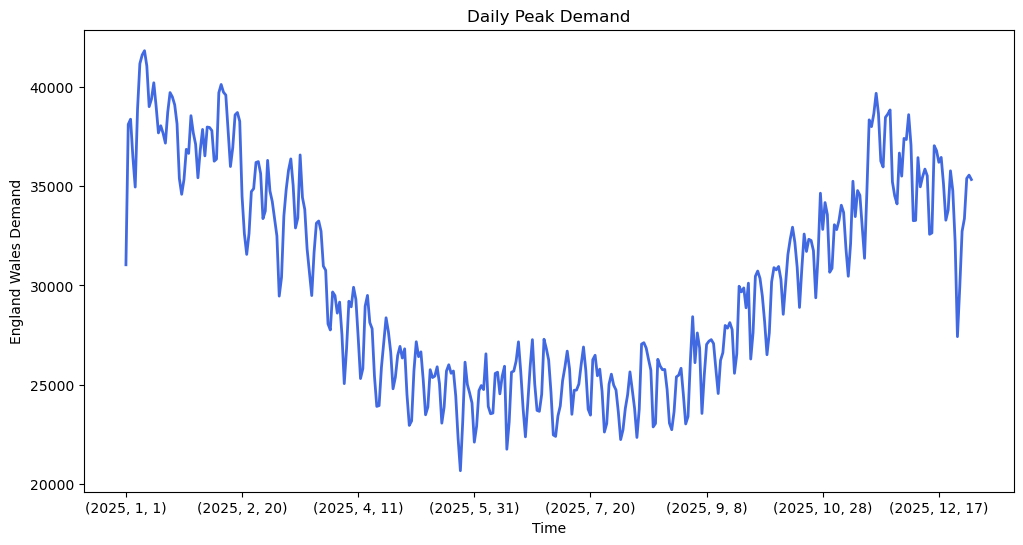

In [21]:
# daily peak demand plot

plt.figure(figsize=[12,6])

df.groupby(['year', 'month', 'day'])['england_wales_demand'].max().plot(linewidth=2, color='royalblue')

plt.xlabel('Time')
plt.ylabel('England Wales Demand')
plt.title('Daily Peak Demand')

In [23]:
# calculating daily min demand

df.groupby('timestamp')['england_wales_demand'].min()

timestamp
2025-01-01 00:00:00    19918
2025-01-01 00:30:00    20167
2025-01-01 01:00:00    20328
2025-01-01 01:30:00    19460
2025-01-01 02:00:00    18654
                       ...  
2025-12-31 21:30:00    26868
2025-12-31 22:00:00    25722
2025-12-31 22:30:00    25049
2025-12-31 23:00:00    23955
2025-12-31 23:30:00    23230
Name: england_wales_demand, Length: 17518, dtype: int64

In [29]:
# calculating daily spread

df['daily_spread'] = (df.groupby('day')['england_wales_demand'].max()) - (df.groupby('day')['england_wales_demand'].min())
df.head(20)

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand,demand_change_30m,daily_spread
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,True,NaN,NaN,NaN,19918.000000,5405,0.271363,14513,NaN,NaN
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,True,19918.0,NaN,NaN,20042.500000,5358,0.265682,14809,249.0,21368.0
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,True,20167.0,19918.0,NaN,20137.666667,5237,0.257625,15091,161.0,22683.0
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,True,20328.0,20167.0,NaN,19968.250000,5115,0.262847,14345,-868.0,23771.0
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,True,19460.0,20328.0,NaN,19705.400000,5080,0.272328,13574,-806.0,23419.0
5,2025-01-01 02:30:00,6,19214,24562,18248,5044,6606,0,19270,0,...,True,18654.0,19460.0,NaN,19462.500000,5044,0.276414,13204,-406.0,25869.0
6,2025-01-01 03:00:00,7,18874,24258,17855,4972,6606,0,19270,0,...,True,18248.0,18654.0,NaN,19232.857143,4972,0.278465,12883,-393.0,25538.0
7,2025-01-01 03:30:00,8,18448,24015,17367,4900,6606,0,19270,0,...,True,17855.0,18248.0,NaN,18999.625000,4900,0.282144,12467,-488.0,26378.0
8,2025-01-01 04:00:00,9,17844,24100,16774,4815,6606,0,19270,0,...,True,17367.0,17855.0,NaN,18752.333333,4815,0.287051,11959,-593.0,27109.0
9,2025-01-01 04:30:00,10,17545,23924,16489,4730,6606,0,19270,0,...,True,16774.0,17367.0,NaN,18526.000000,4730,0.286858,11759,-285.0,29311.0


In [35]:
# calculating load factor

df['load_factor'] = df.groupby('day')['england_wales_demand'].mean() / df.groupby('day')['england_wales_demand'].max()
df.head(20)

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand,demand_change_30m,daily_spread,load_factor
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,NaN,NaN,NaN,19918.000000,5405,0.271363,14513,NaN,NaN,NaN
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,19918.0,NaN,NaN,20042.500000,5358,0.265682,14809,249.0,21368.0,0.651909
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,20167.0,19918.0,NaN,20137.666667,5237,0.257625,15091,161.0,22683.0,0.615470
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,20328.0,20167.0,NaN,19968.250000,5115,0.262847,14345,-868.0,23771.0,0.629484
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,19460.0,20328.0,NaN,19705.400000,5080,0.272328,13574,-806.0,23419.0,0.614771
5,2025-01-01 02:30:00,6,19214,24562,18248,5044,6606,0,19270,0,...,18654.0,19460.0,NaN,19462.500000,5044,0.276414,13204,-406.0,25869.0,0.615238
6,2025-01-01 03:00:00,7,18874,24258,17855,4972,6606,0,19270,0,...,18248.0,18654.0,NaN,19232.857143,4972,0.278465,12883,-393.0,25538.0,0.603039
7,2025-01-01 03:30:00,8,18448,24015,17367,4900,6606,0,19270,0,...,17855.0,18248.0,NaN,18999.625000,4900,0.282144,12467,-488.0,26378.0,0.587778
8,2025-01-01 04:00:00,9,17844,24100,16774,4815,6606,0,19270,0,...,17367.0,17855.0,NaN,18752.333333,4815,0.287051,11959,-593.0,27109.0,0.572154
9,2025-01-01 04:30:00,10,17545,23924,16489,4730,6606,0,19270,0,...,16774.0,17367.0,NaN,18526.000000,4730,0.286858,11759,-285.0,29311.0,0.567122


In [37]:
# top 20 highest demand days

df.sort_values('england_wales_demand', ascending=False)[['timestamp', 'england_wales_demand']].head(20)

,timestamp,england_wales_demand
418,2025-01-09 17:00:00,41835
419,2025-01-09 17:30:00,41811
371,2025-01-08 17:30:00,41620
370,2025-01-08 17:00:00,41614
420,2025-01-09 18:00:00,41479
417,2025-01-09 16:30:00,41428
372,2025-01-08 18:00:00,41389
369,2025-01-08 16:30:00,41384
421,2025-01-09 18:30:00,41295
323,2025-01-07 17:30:00,41182


In [39]:
# top 20 lowest days

df.sort_values('england_wales_demand', ascending=True)[['timestamp', 'england_wales_demand']].head(20)

,timestamp,england_wales_demand
6939,2025-05-25 14:30:00,12040
11354,2025-08-25 14:00:00,12093
4538,2025-04-05 14:00:00,12119
6938,2025-05-25 14:00:00,12276
6218,2025-05-10 14:00:00,12355
11353,2025-08-25 13:30:00,12373
4539,2025-04-05 14:30:00,12403
11355,2025-08-25 14:30:00,12430
6937,2025-05-25 13:30:00,12458
11352,2025-08-25 13:00:00,12496


In [43]:
# exploring renewable curtialment opportunities (renewable_pct is high but demand is low)

df[['england_wales_demand', 'renewable_pct']].describe()

# so we filter for renewable_pct > 75th percentile and demand < 25th percentile

,england_wales_demand,renewable_pct
count,17520.000000,17520.000000
mean,23996.221975,0.188627
std,5650.814832,0.192251
min,12040.000000,0.004044
25%,19638.000000,0.062087
50%,22904.000000,0.116494
75%,27386.250000,0.237250
max,41835.000000,1.356076


In [45]:
df[(df['england_wales_demand'] < 19638.000000) & (df['renewable_pct'] > 0.237250)]

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand,demand_change_30m,daily_spread,load_factor
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,20328.0,20167.0,NaN,19968.250000,5115,0.262847,14345,-868.0,23771.0,0.629484
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,19460.0,20328.0,NaN,19705.400000,5080,0.272328,13574,-806.0,23419.0,0.614771
5,2025-01-01 02:30:00,6,19214,24562,18248,5044,6606,0,19270,0,...,18654.0,19460.0,NaN,19462.500000,5044,0.276414,13204,-406.0,25869.0,0.615238
6,2025-01-01 03:00:00,7,18874,24258,17855,4972,6606,0,19270,0,...,18248.0,18654.0,NaN,19232.857143,4972,0.278465,12883,-393.0,25538.0,0.603039
7,2025-01-01 03:30:00,8,18448,24015,17367,4900,6606,0,19270,0,...,17855.0,18248.0,NaN,18999.625000,4900,0.282144,12467,-488.0,26378.0,0.587778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16664,2025-12-14 04:00:00,9,19196,24621,18636,4863,6606,0,22040,0,...,19203.0,19405.0,20878.0,25445.812500,4863,0.260947,13773,-567.0,NaN,NaN
16665,2025-12-14 04:30:00,10,19142,24583,18534,4808,6606,0,22040,0,...,18636.0,19203.0,20743.0,25399.791667,4808,0.259415,13726,-102.0,NaN,NaN
16666,2025-12-14 05:00:00,11,19150,24732,18542,4747,6606,0,22040,0,...,18534.0,18636.0,20434.0,25360.375000,4747,0.256013,13795,8.0,NaN,NaN
16667,2025-12-14 05:30:00,12,19185,24780,18522,4686,6606,0,22040,0,...,18542.0,18534.0,20728.0,25314.416667,4686,0.252996,13836,-20.0,NaN,NaN


In [49]:
# investigating average demand before and after the weekends (monday and friday)
df[(df['weekday'] == 0) | (df['weekday'] == 4)][['england_wales_demand']].mean()

england_wales_demand    24359.801161
dtype: float64

In [55]:
# investigating average demand in the middle of the week (tuesday, wednesday, thursday)
df[(df['weekday'] == 1) | (df['weekday'] == 2) | (df['weekday'] == 3)][['england_wales_demand']].mean()

england_wales_demand    24983.903397
dtype: float64

In [61]:
# detecting outliers using IQR (for demand)

q25 = df['england_wales_demand'].quantile(0.25)
q75 = df['england_wales_demand'].quantile(0.75)

ub = q75 + (1.5 * (q75 - q25))
lb = q25 - (1.5 * (q75 - q25))

def is_outlier(demand):
    if demand > ub or demand < lb:
        return True
    else:
        return False

df['is_demand_outlier'] = df['england_wales_demand'].apply(is_outlier)

df.head(20)

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand,demand_change_30m,daily_spread,load_factor,is_demand_outlier
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,NaN,NaN,19918.000000,5405,0.271363,14513,NaN,NaN,NaN,False
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,NaN,NaN,20042.500000,5358,0.265682,14809,249.0,21368.0,0.651909,False
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,19918.0,NaN,20137.666667,5237,0.257625,15091,161.0,22683.0,0.615470,False
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,20167.0,NaN,19968.250000,5115,0.262847,14345,-868.0,23771.0,0.629484,False
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,20328.0,NaN,19705.400000,5080,0.272328,13574,-806.0,23419.0,0.614771,False
5,2025-01-01 02:30:00,6,19214,24562,18248,5044,6606,0,19270,0,...,19460.0,NaN,19462.500000,5044,0.276414,13204,-406.0,25869.0,0.615238,False
6,2025-01-01 03:00:00,7,18874,24258,17855,4972,6606,0,19270,0,...,18654.0,NaN,19232.857143,4972,0.278465,12883,-393.0,25538.0,0.603039,False
7,2025-01-01 03:30:00,8,18448,24015,17367,4900,6606,0,19270,0,...,18248.0,NaN,18999.625000,4900,0.282144,12467,-488.0,26378.0,0.587778,False
8,2025-01-01 04:00:00,9,17844,24100,16774,4815,6606,0,19270,0,...,17855.0,NaN,18752.333333,4815,0.287051,11959,-593.0,27109.0,0.572154,False
9,2025-01-01 04:30:00,10,17545,23924,16489,4730,6606,0,19270,0,...,17367.0,NaN,18526.000000,4730,0.286858,11759,-285.0,29311.0,0.567122,False


In [63]:
df[df['is_demand_outlier'] == True]

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand,demand_change_30m,daily_spread,load_factor,is_demand_outlier
321,2025-01-07 16:30:00,34,43317,45428,39938,2805,6606,0,19280,0,...,37695.0,38438.0,31712.645833,2805,0.070234,37133,1165.0,NaN,NaN,True
322,2025-01-07 17:00:00,35,44559,46661,40976,2867,6606,0,19280,0,...,38773.0,38895.0,31756.000000,2867,0.069968,38109,1038.0,NaN,NaN,True
323,2025-01-07 17:30:00,36,44730,46836,41182,2929,6606,0,19280,0,...,39938.0,38850.0,31804.583333,2929,0.071123,38253,206.0,NaN,NaN,True
324,2025-01-07 18:00:00,37,44067,46173,40618,2940,6606,0,19280,0,...,40976.0,38679.0,31844.979167,2940,0.072382,37678,-564.0,NaN,NaN,True
325,2025-01-07 18:30:00,38,43685,45786,40302,2951,6606,0,19280,0,...,41182.0,38021.0,31892.500000,2951,0.073222,37351,-316.0,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,2025-02-13 18:30:00,38,42872,44600,39181,1455,6606,0,19687,0,...,39558.0,39132.0,32338.125000,1455,0.037135,37726,-419.0,NaN,NaN,True
15537,2025-11-20 16:30:00,34,43723,46600,39688,1993,6606,0,21816,0,...,37166.0,38216.0,31813.416667,1993,0.050217,37695,1174.0,NaN,NaN,True
15538,2025-11-20 17:00:00,35,43720,46736,39564,1969,6606,0,21816,0,...,38514.0,38663.0,31832.187500,1969,0.049767,37595,-124.0,NaN,NaN,True
15539,2025-11-20 17:30:00,36,43510,46552,39394,1945,6606,0,21816,0,...,39688.0,38507.0,31850.666667,1945,0.049373,37449,-170.0,NaN,NaN,True


In [71]:
# detecting outliers using isolation forest (unsupervised ml algorithm)

from sklearn.ensemble import IsolationForest

feature = df[['england_wales_demand']]

isolation_forest = IsolationForest(contamination=0.01)

isolation_forest.fit(feature)

isolation_forest.predict(feature)

array([1, 1, 1, ..., 1, 1, 1])

In [73]:
# saving the csv file

df.to_csv('power_trading_demand_data_2025.csv')
print('CSV saved successfully.')

CSV saved successfully.
